## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

##**Importing necessary libraries**

In [105]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [106]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

##**Loading the dataset**

In [107]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Loan_Modelling.csv'

data = pd.read_csv(path)
df = data.copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Data Overview**

####**Checking the first and last 5 columns of the data**

In [108]:
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [109]:
df.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


###**Observations:**
The dataset consists of relevant user data including demographic details like age, income, education, and work experience, as well as financial information such as mortgage, Avergae credit card spending, securities account, and CD account, which banks may use to assess for potential loan applications.

###**Sanity Check:**
The first and last five rows of the data shows no obvious errors or issues with the data.

###**Shape of the Dataset**

In [110]:
df.shape

(5000, 14)

###**Check the data types of the columns**

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


###**Observations:**
* There are 5000 rows and 14 columns. Out of the 14 columns 13 are of integer type and 1 column is float.

* As we can see there are 5000 non-null values in each column indicating no missing values in the data.

* Columns such as Education, Personal_loan, Securities_Account,CD_Account,Online and CreditCard appear to be categorical rather than numerical.Converting these columns to categorical is necessary for the analysis.

* Zip code is stored as int64 but should be treated as a nominal categorical variable, so that its numeric values won't impact analysis results.

##**Statistical Summary of the data**

In [112]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


###**Observations:**

* The average age of customers is 45.3 with the minimum at 23 and maximum at 67.

* The average work experience is 20 years. But the negative value for min experience indicates that it could be a data entry error as experience cannot be a negative value.

* The average income level is 73K with the min income at 8K and max income at 224K. The high standard diversion and large difference in the income ranges indicates huge variations in income levels and the presence of potential outliers.
* The mean mortgase is 56k and again a high standard deviation (101.7K) and the mortgages ranges from 0 to 635K. The huge variations indicate that there might be several customers with no mortgage.


###**Checking for duplicates**

In [113]:
df.duplicated().sum()

np.int64(0)

###**Observations:**
* There are no duplicates in the data.

# **Data PreProcessing**

###**Drop ID column**

In [114]:
df.drop('ID',axis=1,inplace=True)

###**Observations:**
The ID column is dropped from the data as it will not be used in the decision tree analysis.

###**Convert Zip Code column to Categorical**

In [115]:
df['ZIPCode'].nunique()

467

###**Observations:**
There are 467 unique zip codes. Converting them to categorical type still results in a large number of distinct values, making grouping and inference difficult. To identify patterns, the zip code can be reduced to the first two digits, which represent regions and allow for more effective grouping of the data.

In [116]:
# convert zip code to string to slice the values.
df["ZIPCode"] = df["ZIPCode"].astype(str)

print(
    "Number of unique values if we take first two digits of ZIPCode: ",
    df["ZIPCode"].str[0:2].nunique(),
)

df["ZIPCode"] = df["ZIPCode"].str[0:2]

# Lastly, convert the zip code column to categorical data type.
df["ZIPCode"] = df["ZIPCode"].astype("category")

Number of unique values if we take first two digits of ZIPCode:  7


###**Observations:**
We can see that the number of unique zip codes have reduced to 7 broader regional values.


###**Converting Few Other Columns to Categorical**

In [117]:
categories = ['Education','Personal_Loan','Securities_Account','CD_Account','Online','CreditCard']
df[categories] = df[categories].astype('category')

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   ZIPCode             5000 non-null   category
 4   Family              5000 non-null   int64   
 5   CCAvg               5000 non-null   float64 
 6   Education           5000 non-null   category
 7   Mortgage            5000 non-null   int64   
 8   Personal_Loan       5000 non-null   category
 9   Securities_Account  5000 non-null   category
 10  CD_Account          5000 non-null   category
 11  Online              5000 non-null   category
 12  CreditCard          5000 non-null   category
dtypes: category(7), float64(1), int64(5)
memory usage: 269.8 KB


###**Observations:**
We can see that columns (Education,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard and ZipCode) now categorical data type in the dataframe.

###**Clean the negative values in Experience column**

In [119]:
df[df['Experience'] < 0]['Experience'].value_counts()

,count
Experience,
-1,33
-2,15
-3,4


###**Observations**

There are a total of 52 negative values in the Experience column. We can replace all the negative values with its equivalent positive values.

In [120]:
##Replace negative values in Experience value with the positive value.
df['Experience'].replace(-1,1,inplace=True)
df['Experience'].replace(-2,2,inplace=True)
df['Experience'].replace(-3,3,inplace=True)

## **Exploratory Data Analysis.**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

In [121]:
def histogram_boxplot(data,feature,figsize=(12,7),kde=False,bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """

    #Create a figure with two subplots (one for boxplot and another for histogram)
    fig,(ax_box,ax_hist) = plt.subplots(nrows=2,sharex=True,gridspec_kw={'height_ratios':[0.25,0.75]},figsize=figsize)

    #creata a boxplot as the first subplot
    sns.boxplot(data=data,x=feature,ax=ax_box,showmeans=True,color='violet')
    # create a histogram as the second subplot
    if bins:
      sns.histplot(data=data,x=feature,ax=ax_hist,kde=kde,bins=bins,palette='winter')
    else:
      sns.histplot(data=data,x=feature,ax=ax_hist,kde=kde,palette='winter')

    #display the mean and median lines on the histogram plot:
    ax_hist.axvline(x=data[feature].mean(),color='red',linestyle = '--',label='Mean')
    ax_hist.axvline(x=data[feature].median(),color='blue',linestyle='--',label='Median')

    #display the legend
    ax_hist.legend()

    #display the plot
    plt.show()





In [122]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

##**Univariate Analysis**

###**Age:**

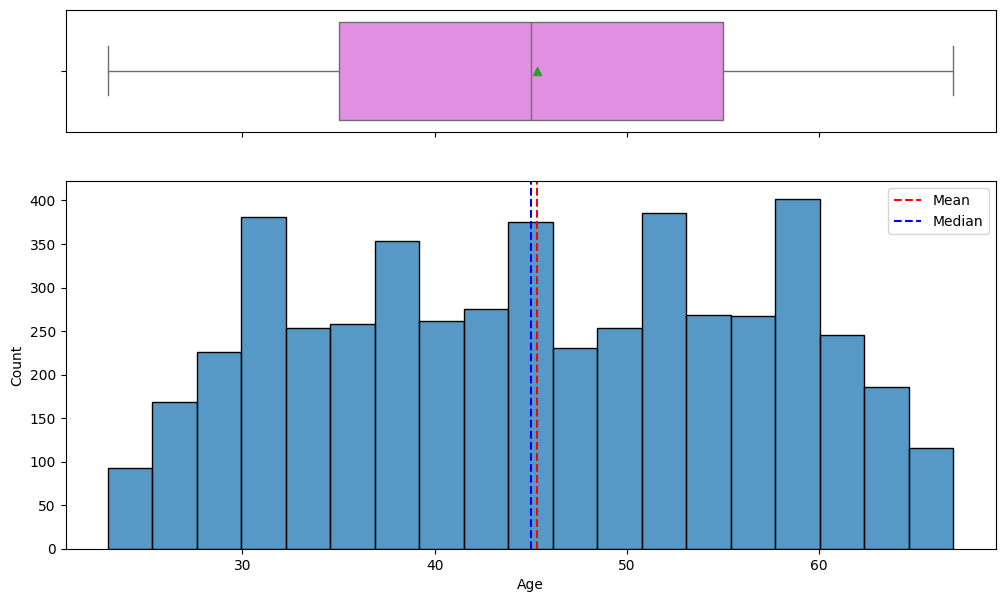

In [123]:
histogram_boxplot(df,'Age')

###**Observations:**
* The plot has few peaks but overall age is a normal distribution.
* Mean and Median age are almost equal at around 45 years.
* There are no outliers in Age.

###**Experience**

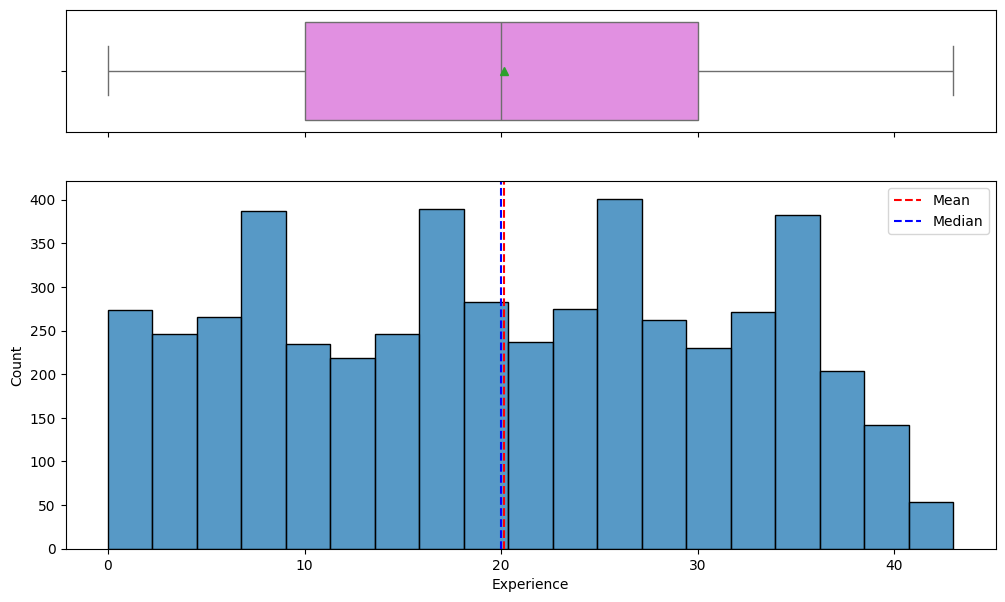

In [124]:
histogram_boxplot(df,'Experience')

###**Observations:**
* Similar to Age, the distribution of Experience is also fairly normal with few peaks.
* Experience ranges from 0 to 45 years with the mean and median approx. at 20 years.
* No outliers detected.

###**Income**

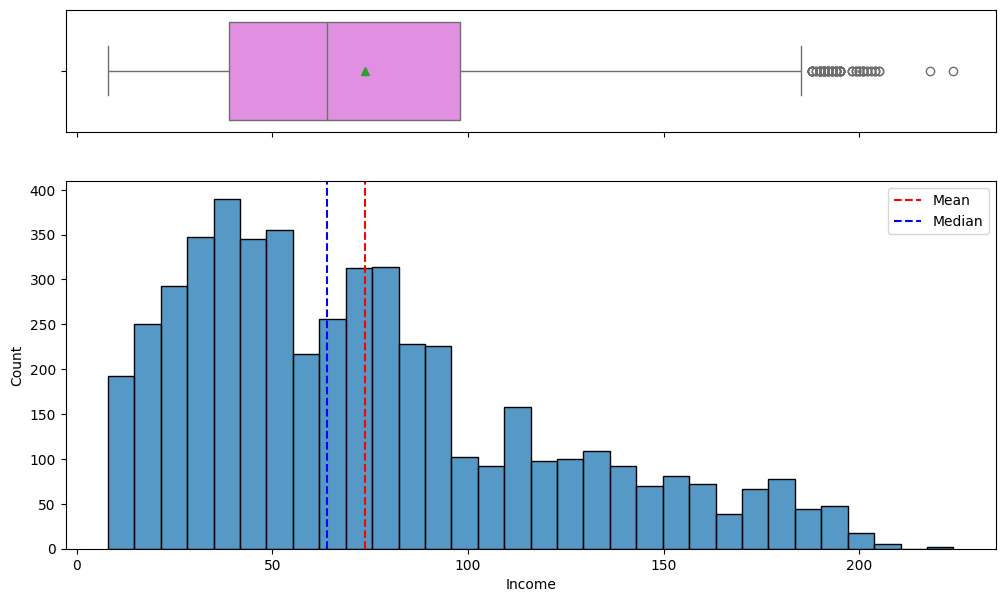

In [125]:
histogram_boxplot(df,'Income')

###**Observations:**

* Income distribution is right skewed with the mean > median. Salary ranges from 39k to 224K.
* 75% of the customers fall under 98K salary range.
* Outliers are seen in the data which indicates the presence of some very high income individuals compared to the larger population of low or middle income groups.

###**CCAvg:**

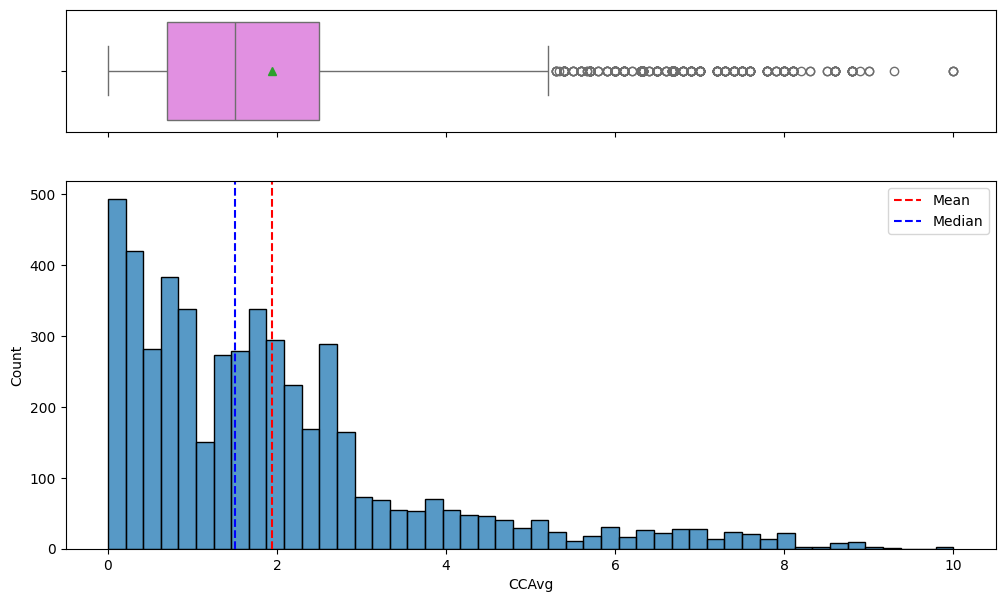

In [126]:
histogram_boxplot(df,'CCAvg')

###**Observations:**
* Average credit card spending is again right skewed where the mean > median.
Credit card spending ranges from 0 to 10K.
* The average spending is around 2000.
* 75% of the population spends less than 2500.
* Outliers are detected in CCAvg.



###**Mortgage**

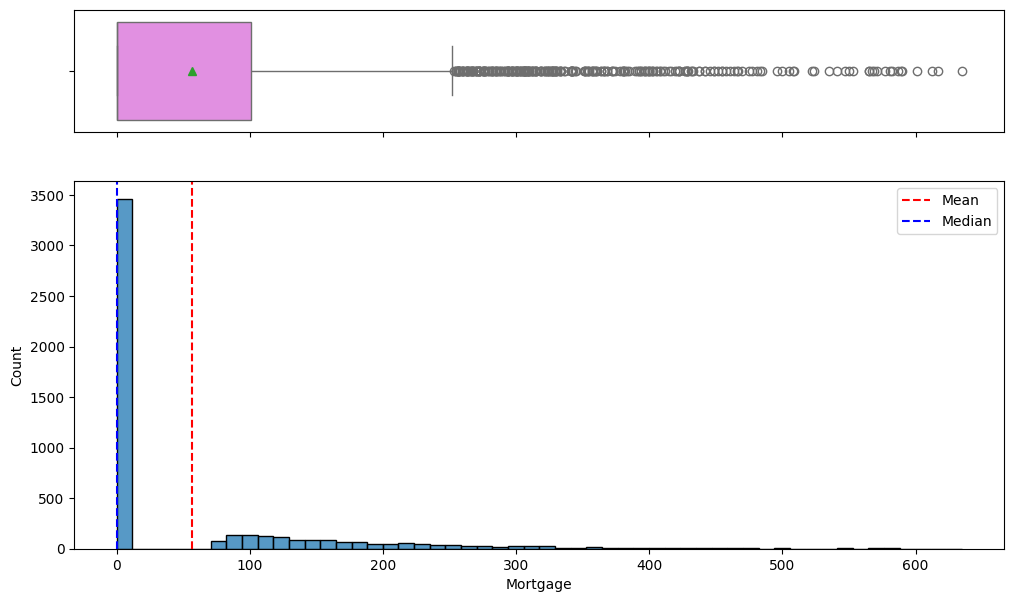

In [127]:
histogram_boxplot(df,'Mortgage')

###**Observations:**
* Mortage is right skewed with the most count at 0. This shows that majority of the customers don't have a mortgage. Mean > Median.
* The mean is at 56K.
* 75% of the mortage is below 101K.
* There are several outliers indicating the presence of mortgages > 100K.


###**Categorical Data Univariate Analysis**

###**Family**

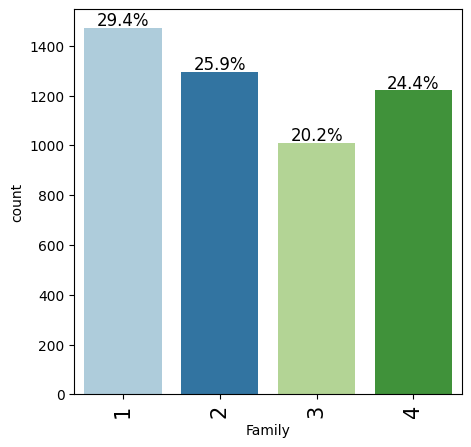

In [128]:
labeled_barplot(df,'Family',perc=True)

###**Observations:**
* There are 4 family sizes - 1,2,3,4.
* Family size of 1 has the highest number of customers (1400) followed by size 2 (1300) and size 4 (1200).
* Most customers have a 2+ family size.

###**Education**

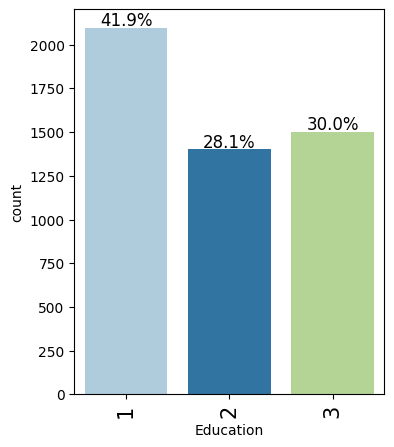

In [129]:
labeled_barplot(df,'Education',perc=True)

###**Observations:**
* There are three education levels - Undergrad, Graduates and Advanced professionals.
* The common category is the undergrad(2200) at 41.9%.
* Graduates and Advances professionals together account for 58.1% of the data.

###**Securities Account**

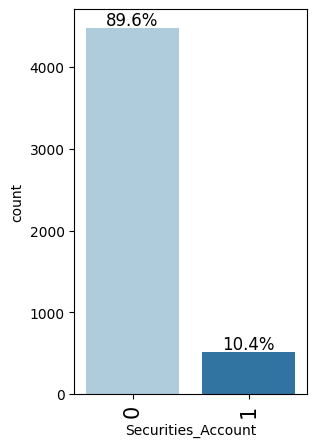

In [130]:
labeled_barplot(df,'Securities_Account',perc=True)

###**Observations:**
* Majority of the customers don't have a securities account. Only 10.4% that is around 500 have securities account.

###**CD_Account**

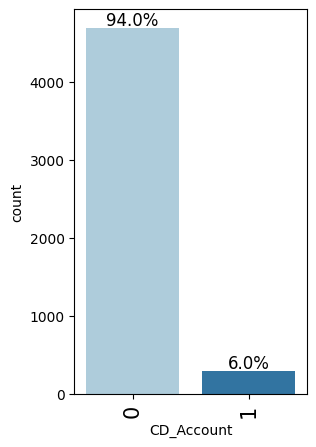

In [131]:
labeled_barplot(df,'CD_Account',perc=True)

###**Observations:**
Only 6% of the customers hold a current deposit account. There remaining 94% don't have a current deposit account.

###**Online**

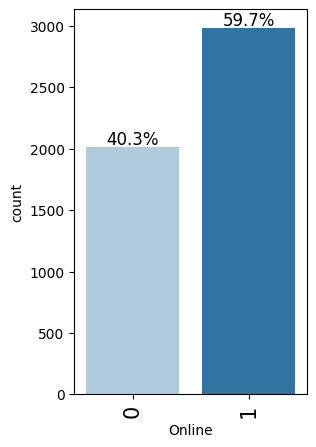

In [132]:
labeled_barplot(df,'Online',perc=True)

###**Observations:**
* Majortiy of the users (59.7%) have access to internet banking.

###**Credit Card**

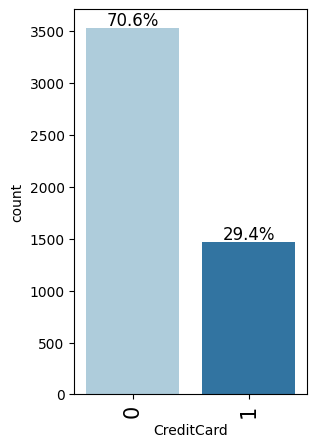

In [133]:
labeled_barplot(df,'CreditCard',perc=True)

###**Observations:**
* Around 3500 customers (70.6%) in the dataset do not own a credit card with other banks.

###**Zip Code**

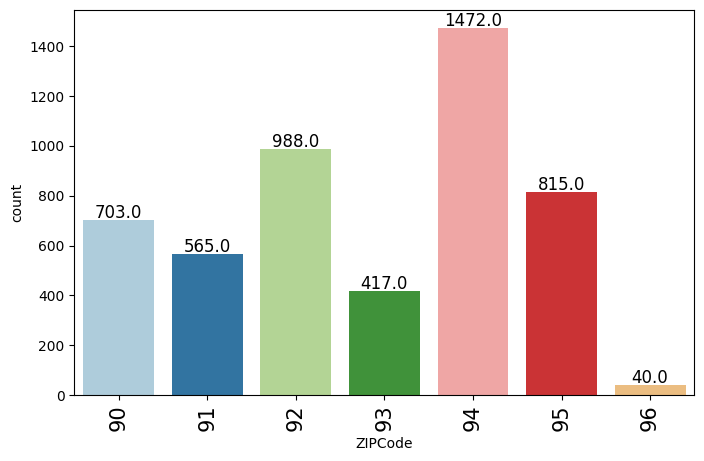

In [134]:
labeled_barplot(df,'ZIPCode')

##**Observations:**
Zip Code region 94 has the higest number of customers at 1472.
Region code 96 has the least number of customers at 40.

#**Bivariate Analysis:**

In [135]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [136]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

###**Personal Loan Vs Age**

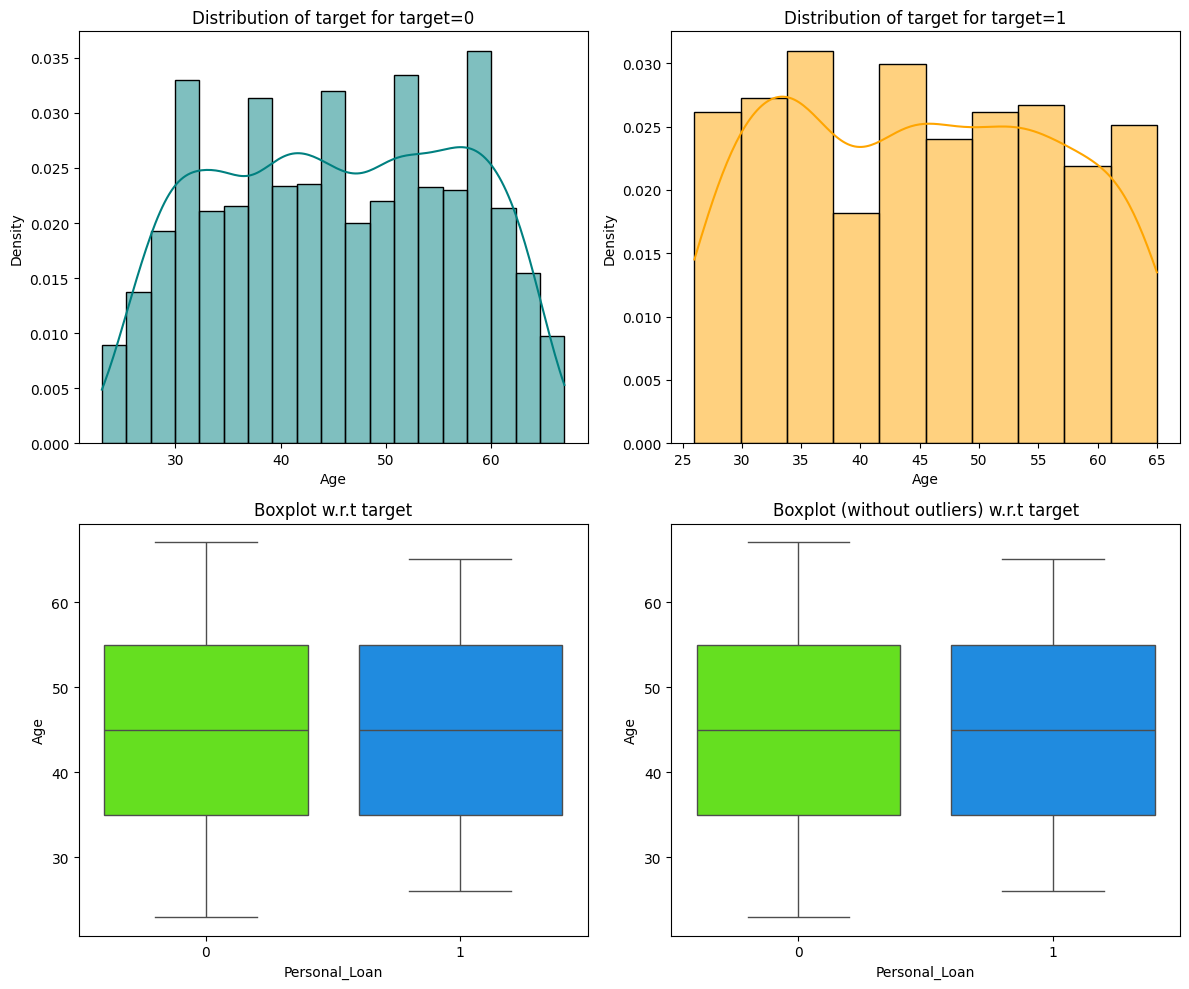

In [137]:
distribution_plot_wrt_target(df,'Age','Personal_Loan')

###**Observations:**

* Age is evenly distributed for both loan takers and non-takers. This shows that age does not influence loan decisions.
* The IQR, mean and median are similar to both the groups which shows that customers of all age groups are equally likely to accept or reject a loan offer.

###**Personal Loan Vs  Education**

Personal_Loan     0    1   All
Education                     
All            4520  480  5000
3              1296  205  1501
2              1221  182  1403
1              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


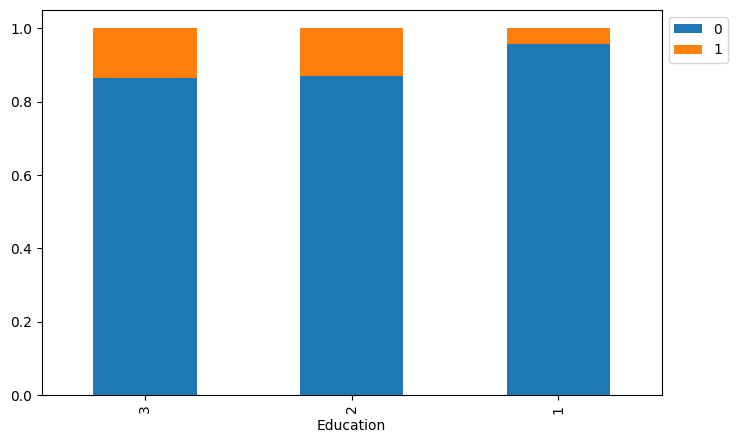

In [138]:
stacked_barplot(df,'Education','Personal_Loan')

###**Observations:**
* There are slightly less loan offer takers among undergrads compared to Grads and advanced professionals. Howervr,education levels doesn't seem to have much impact on loan offers.

###**Personal Loan Vs Experience**

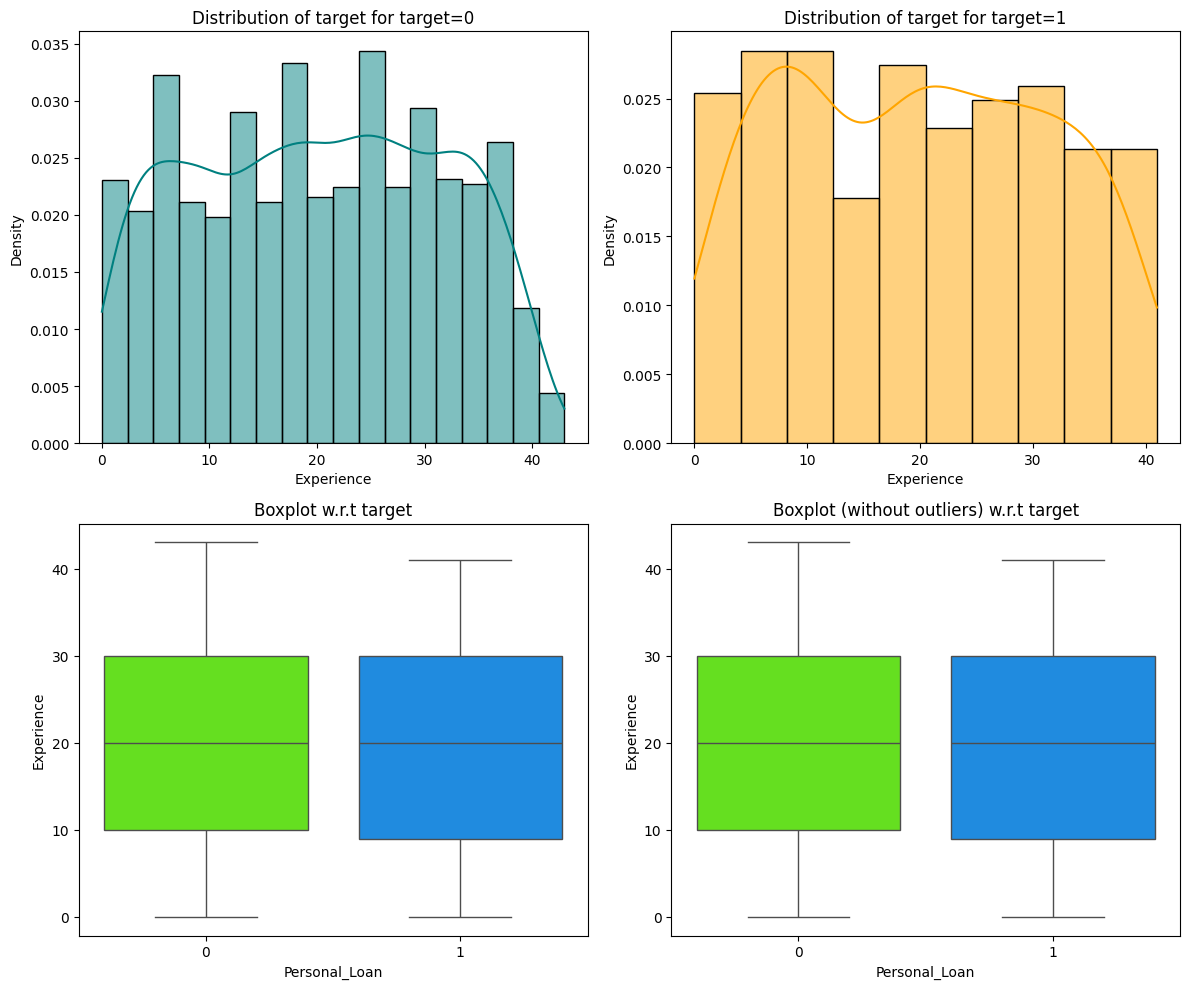

In [139]:
distribution_plot_wrt_target(df,'Experience','Personal_Loan')

###**Observations:**
* Similar to age, Experience is evenly distributed accross loan takers and non-takes. It shows that customers with any level of experience are equally likely to accept or reject a personal loan offer.

###**Personal Loan Vs Income**

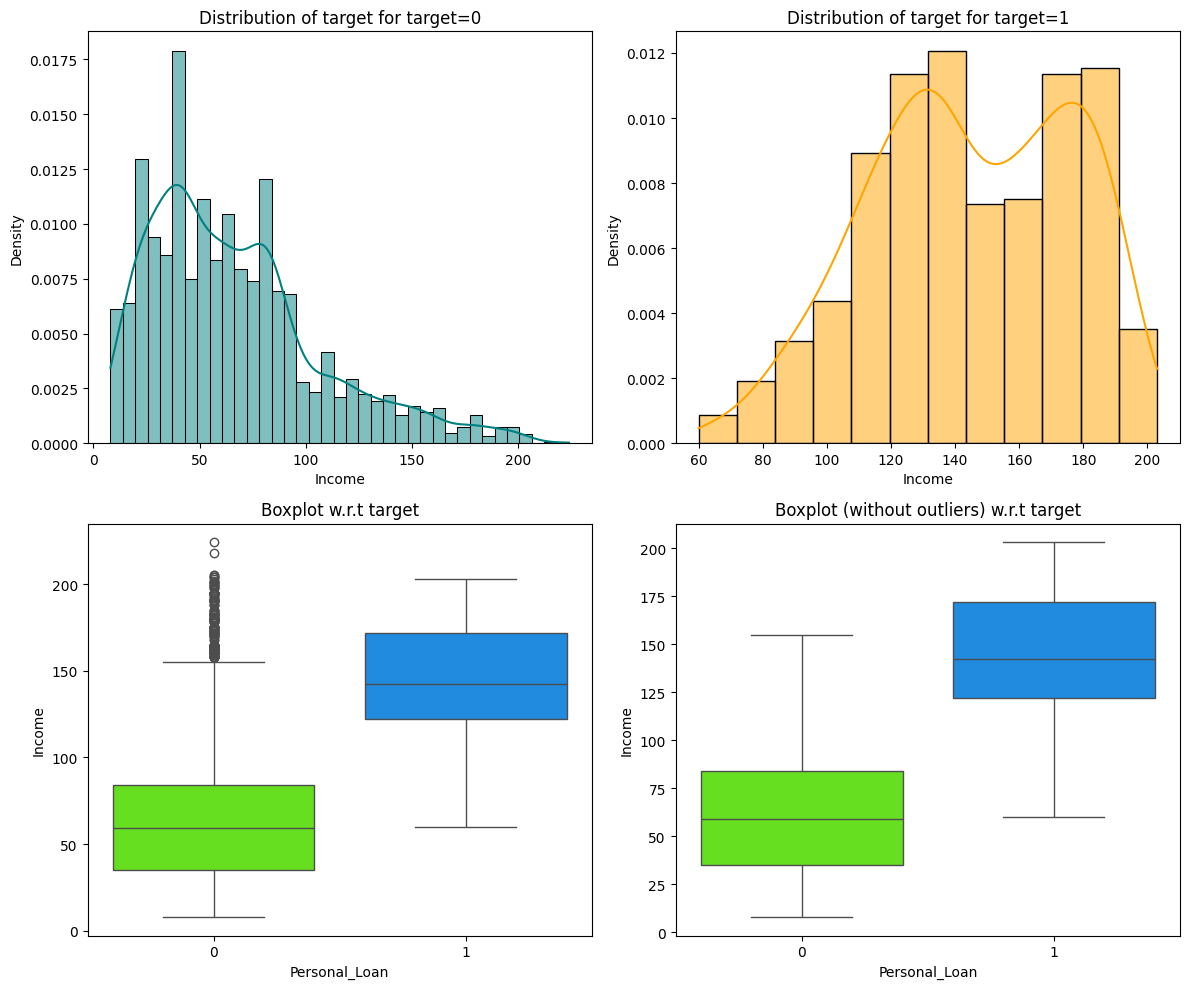

In [140]:
distribution_plot_wrt_target(df,'Income','Personal_Loan')

###**Observations:**
* There is a clear separation of income levels between loan takers and non-takers.
* The plots show that customers that belong to the high income groups > 100K are more like to take a loan offer compared to low income group.

###**Personal Loan Vs Mortgage**



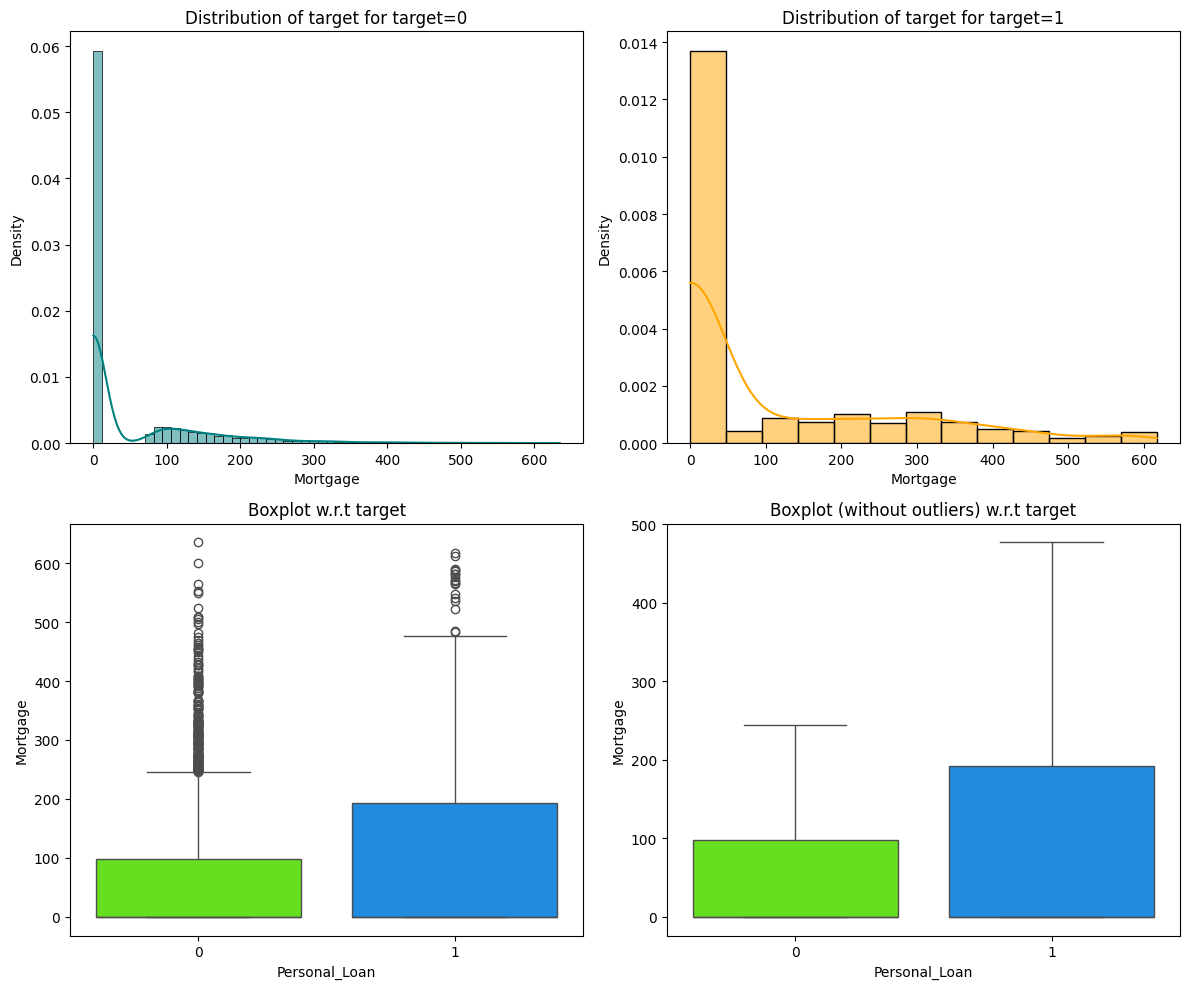

In [141]:
distribution_plot_wrt_target(df,'Mortgage','Personal_Loan')

###**Observations:**
* Personal loan acceptance is somewhat higher for customers with higher mortgages. However, most customers do not have a mortgage, and it remains uncertain whether they will accept loan offers if they obtain one in the future.

###**Personal Loan vs Family**

Personal_Loan     0    1   All
Family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


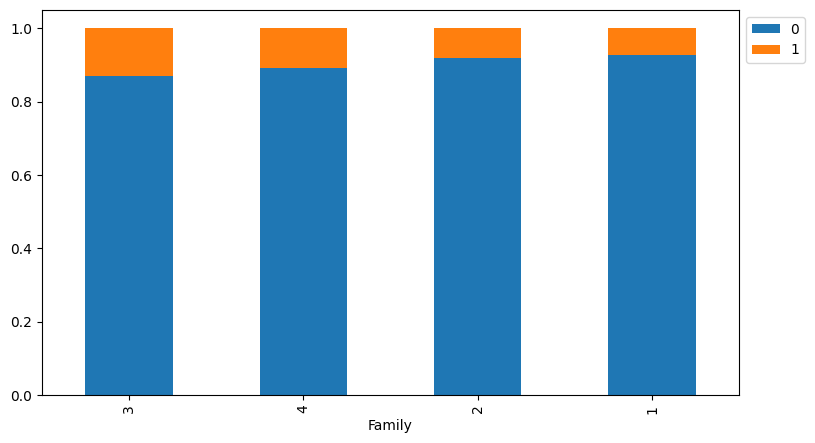

In [142]:
stacked_barplot(df,'Family','Personal_Loan')

###**Observations:**
* Customers with family size of 3 or 4 are more likely take a personal loan compared to family size of 2 or 1. However, family size has a less overall impact on loan acceptance.

###**Personal Loan Vs CCAvg**

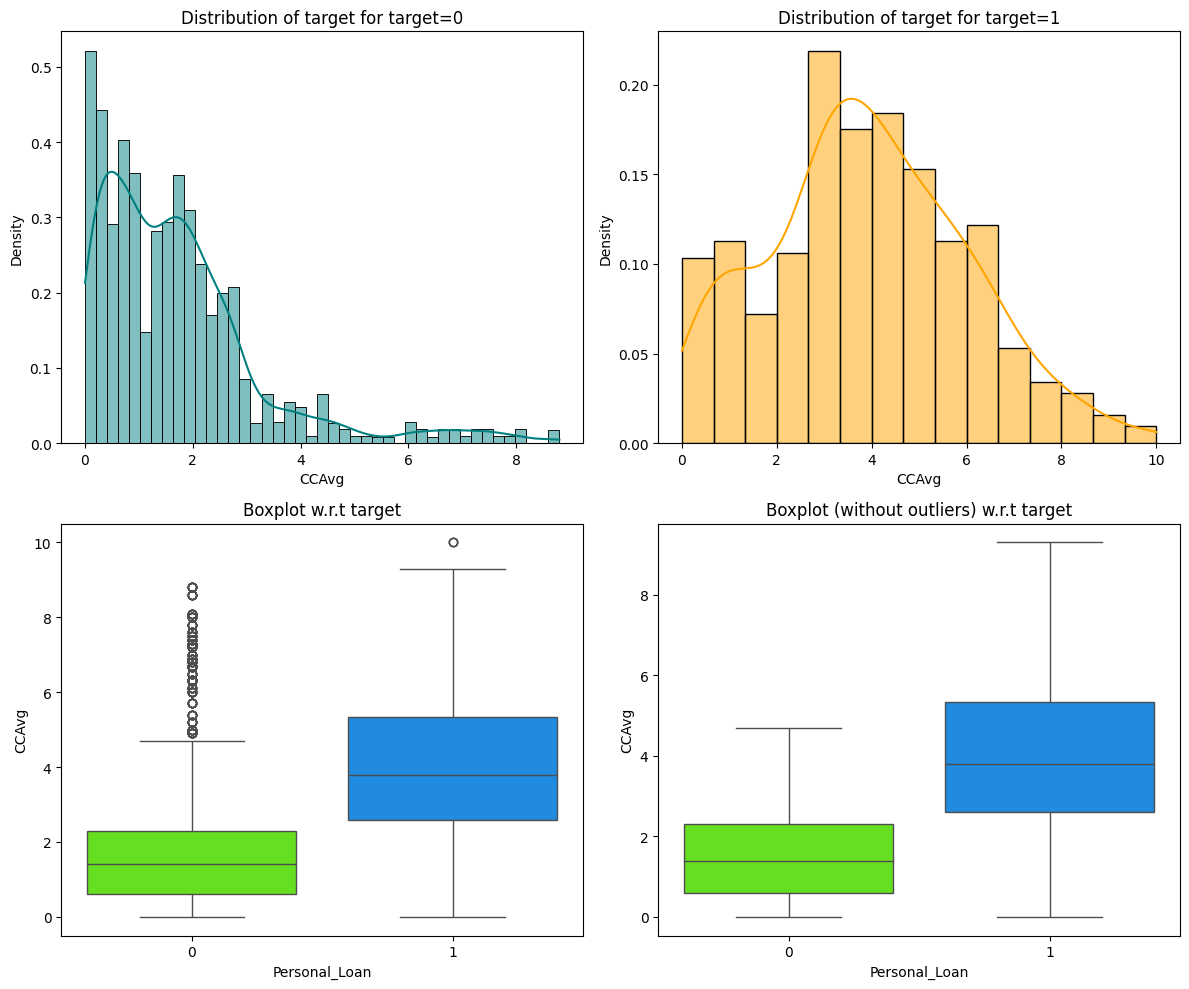

In [143]:
distribution_plot_wrt_target(df,'CCAvg','Personal_Loan')

###**Observations:**
* We can see that customers that have an higher credit card spending average > 2k are more likely to accept a loan offer.
* Interestly individuals whose spending exceeds 6-8k show less interest in loan products. Therefore, it can be inferred that those in the mid-range spending category are more likely to consider personal loan offers.

###**Personal Loan Vs CD Account**

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


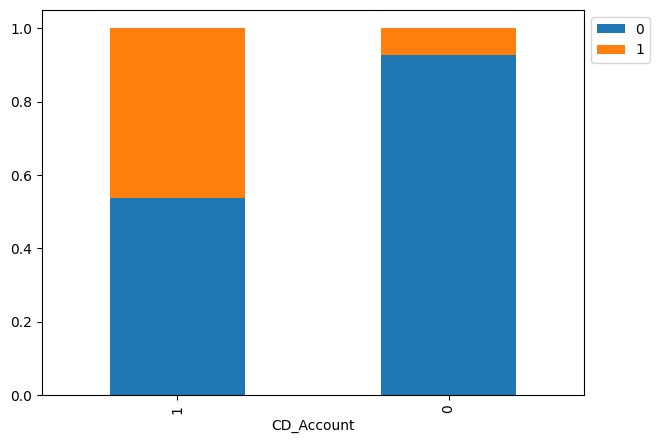

In [144]:
stacked_barplot(df,'CD_Account','Personal_Loan')

###**Observations:**
* Customers that have CD accounts are more likely to take a personal loan offer compared to non-CD account holders.

###**Personal Loan vs Securities Account**

Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


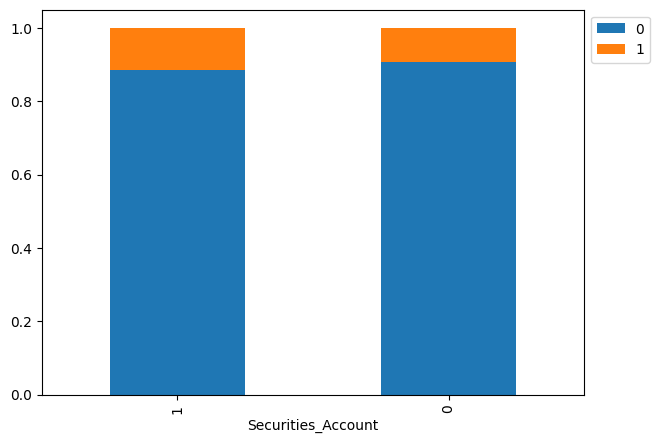

In [145]:
stacked_barplot(df,'Securities_Account','Personal_Loan')

###**Observations:**
* Securities account holders seems to slighlty more receptive to loan offers caompared to non-securities account holders.

###**Personal Loan Vs Online**

Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


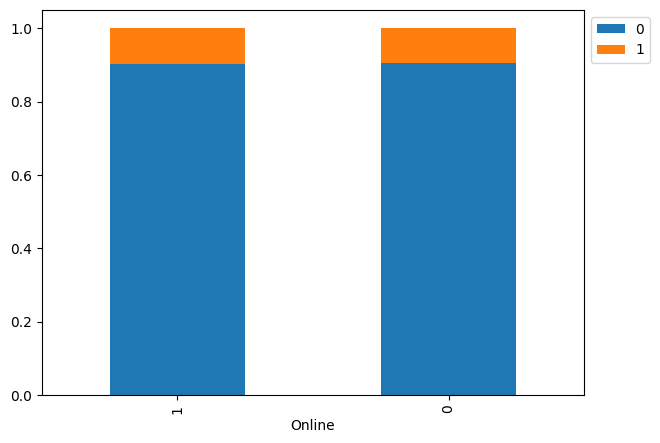

In [146]:
stacked_barplot(df,'Online','Personal_Loan')

###**Observations:**
* Online bankings access seems to have little to no impact on loan offer acceptance.

###**Personal Loan Vs Credit Card**

Personal_Loan     0    1   All
CreditCard                    
All            4520  480  5000
0              3193  337  3530
1              1327  143  1470
------------------------------------------------------------------------------------------------------------------------


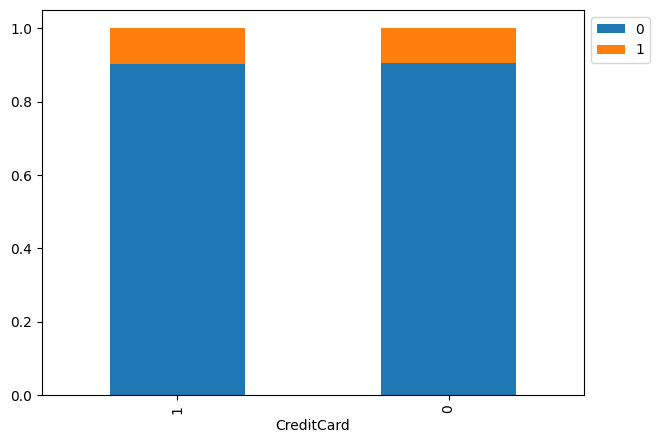

In [147]:
stacked_barplot(df,'CreditCard','Personal_Loan')

###**Observations:**
* The distribution of personal loan acceptance is even accross credit card users and non-credit card users.

###**Correlation Heatmap on Numeric Columns**

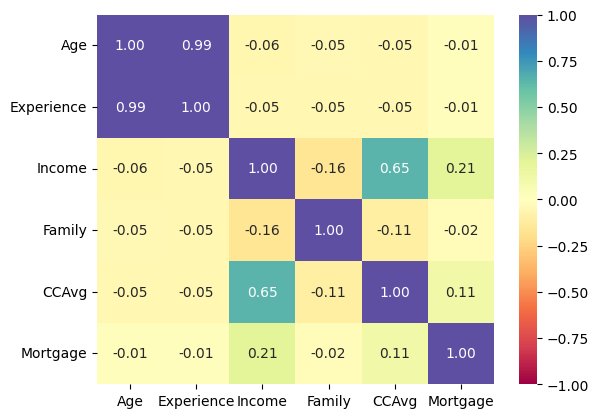

In [148]:
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(),annot=True,vmin=-1, vmax=1, fmt=".2f", cmap='Spectral')
plt.show()

###**Observations:**
* Age and Experience have the highest correlation around 0.99.
* We can also see that CCAvg and Income are the next higly correlated (0.65)
* There is also some correlation between Mortage and Income.
* Small negative correlation between Income and family size and between family and CCAvg are observed.

## **Data Preprocessing**

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

###**Checking for missing values**

In [149]:
df.isnull().sum()

,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0
Securities_Account,0


###**Observations:**

There are no missing values in the data.

##**Outlier Detection**

###**Calculate Inter Quartile Ranges**

In [150]:
Q1 = df.select_dtypes(include=["int64","float64"]).quantile(0.25)
Q3 = df.select_dtypes(include=["int64","float64"]).quantile(0.75)
#Inter Quartile Range
IQR = Q3 - Q1

# Caculate the lower and upper bound for outlier detection
lower_tail = Q1 - 1.5 * IQR
upper_tail = Q3 + 1.5 * IQR


In [151]:
# Calculate percentage of outliers in each column.
(
    (df.select_dtypes(include=["float64", "int64"]) < lower_tail)
    | (df.select_dtypes(include=["float64", "int64"]) > upper_tail)
).sum() / len(df) * 100

,0
Age,0.00
Experience,0.00
Income,1.92
Family,0.00
CCAvg,6.48
Mortgage,5.82


###**Observations:**

* There are no outliers in Age, Experience and Family columns.
* We can see outliers in Income, CCAvg and Mortage. They seem to be valid outliers so we will not treat them as they are proper values.


#Data Preparation for Modelling


In [152]:
df['Age'].corr(df['Experience'])

np.float64(0.9939907211052889)

* Due to the high correlation between Age and Experience, I will drop the Experience column as it is redundant to have both.

In [153]:
#drop the target variable and Experience column as it is highly correlated with Age

X = df.drop(['Personal_Loan','Experience'],axis=1)
Y = df['Personal_Loan']

#Convert the categorical variables to one hot encoding

cat_list = ['Education','ZIPCode']
X = pd.get_dummies(X,columns=cat_list,drop_first=True)
X = X.astype(float)

#split data into train and test datasets and stratify on Y so that both train and test have similar distribution of data

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,stratify=Y,random_state=1)


In [154]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 17)
Shape of test set :  (1500, 17)
Percentage of classes in training set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64


###**Observations:**
* Applied Stratify on Y so that the distribution of classess is similar between train and test data set. After startify the distributions are same.
* We can see that 90.4% of observations are in class 0 (rejected loan offer) and 9.1% in class1 (accepted loan offer). The same distribution can be seen in Test set.

## **Model Building**

##**Decision Tree Classification**

### **Model Evaluation Criterion**

* The marketing team's objective is to optimize their strategy by targeting suitable candidates for personal loans, aiming to minimize false negatives i.e., ignoring potential loan candidates in their marketing campaign (FN).

* Additionally, I would like to assess if we can avoid offering loans to unsuitable or unlikely customers groups (FP), thereby, directing the marketing resources and efforts to focus on appropriate customer segments.

* I would use Recall as the evaluation criterion to reduce false negatives, ensuring qualified customers are not wrongly rejected and maximizing identification of eligible loan customers.

* I would also use F1 Score to balance both false positives and false negatives.


In [155]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [156]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### **Decision Tree (Default)**

In [157]:
model = DecisionTreeClassifier(criterion="gini", random_state=1)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

### **Checking model performance on training set**

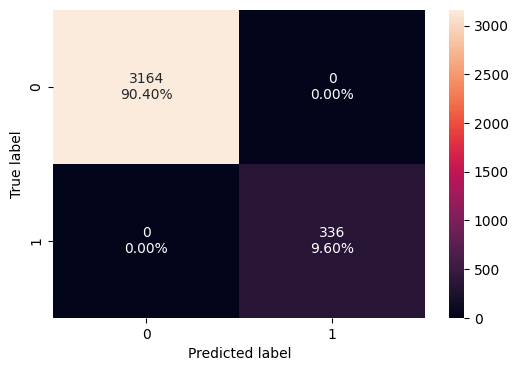

In [158]:
confusion_matrix_sklearn(model,X_train,y_train)

In [159]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


###**Observations:**
* The default model has calssifed all data points in the training set. There are 0 errors in the training set as each data point has been classified correctly.
* This default model is likely an overfitted model.

###**Checking model performance on test set**

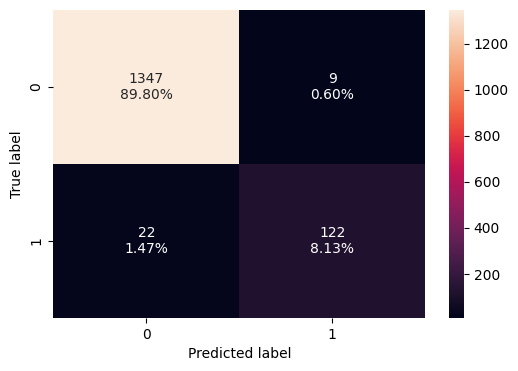

In [160]:
confusion_matrix_sklearn(model,X_test,y_test)

In [161]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model, X_test, y_test
)
decision_tree_default_perf_test


,Accuracy,Recall,Precision,F1
0,0.979333,0.847222,0.931298,0.887273


###**Observations:**
* The model on the test set has slightly lower scores for accuracy, recall, presiciosn and F1 score. The model has not perfectly classifed all the data points and we can see few errors which is to be expected. The default tree seems to have fairly generalized.


###**Visualize Decision Tree**

In [162]:
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['Age', 'Income', 'Family', 'CCAvg', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Education_2', 'Education_3', 'ZIPCode_91', 'ZIPCode_92', 'ZIPCode_93', 'ZIPCode_94', 'ZIPCode_95', 'ZIPCode_96']


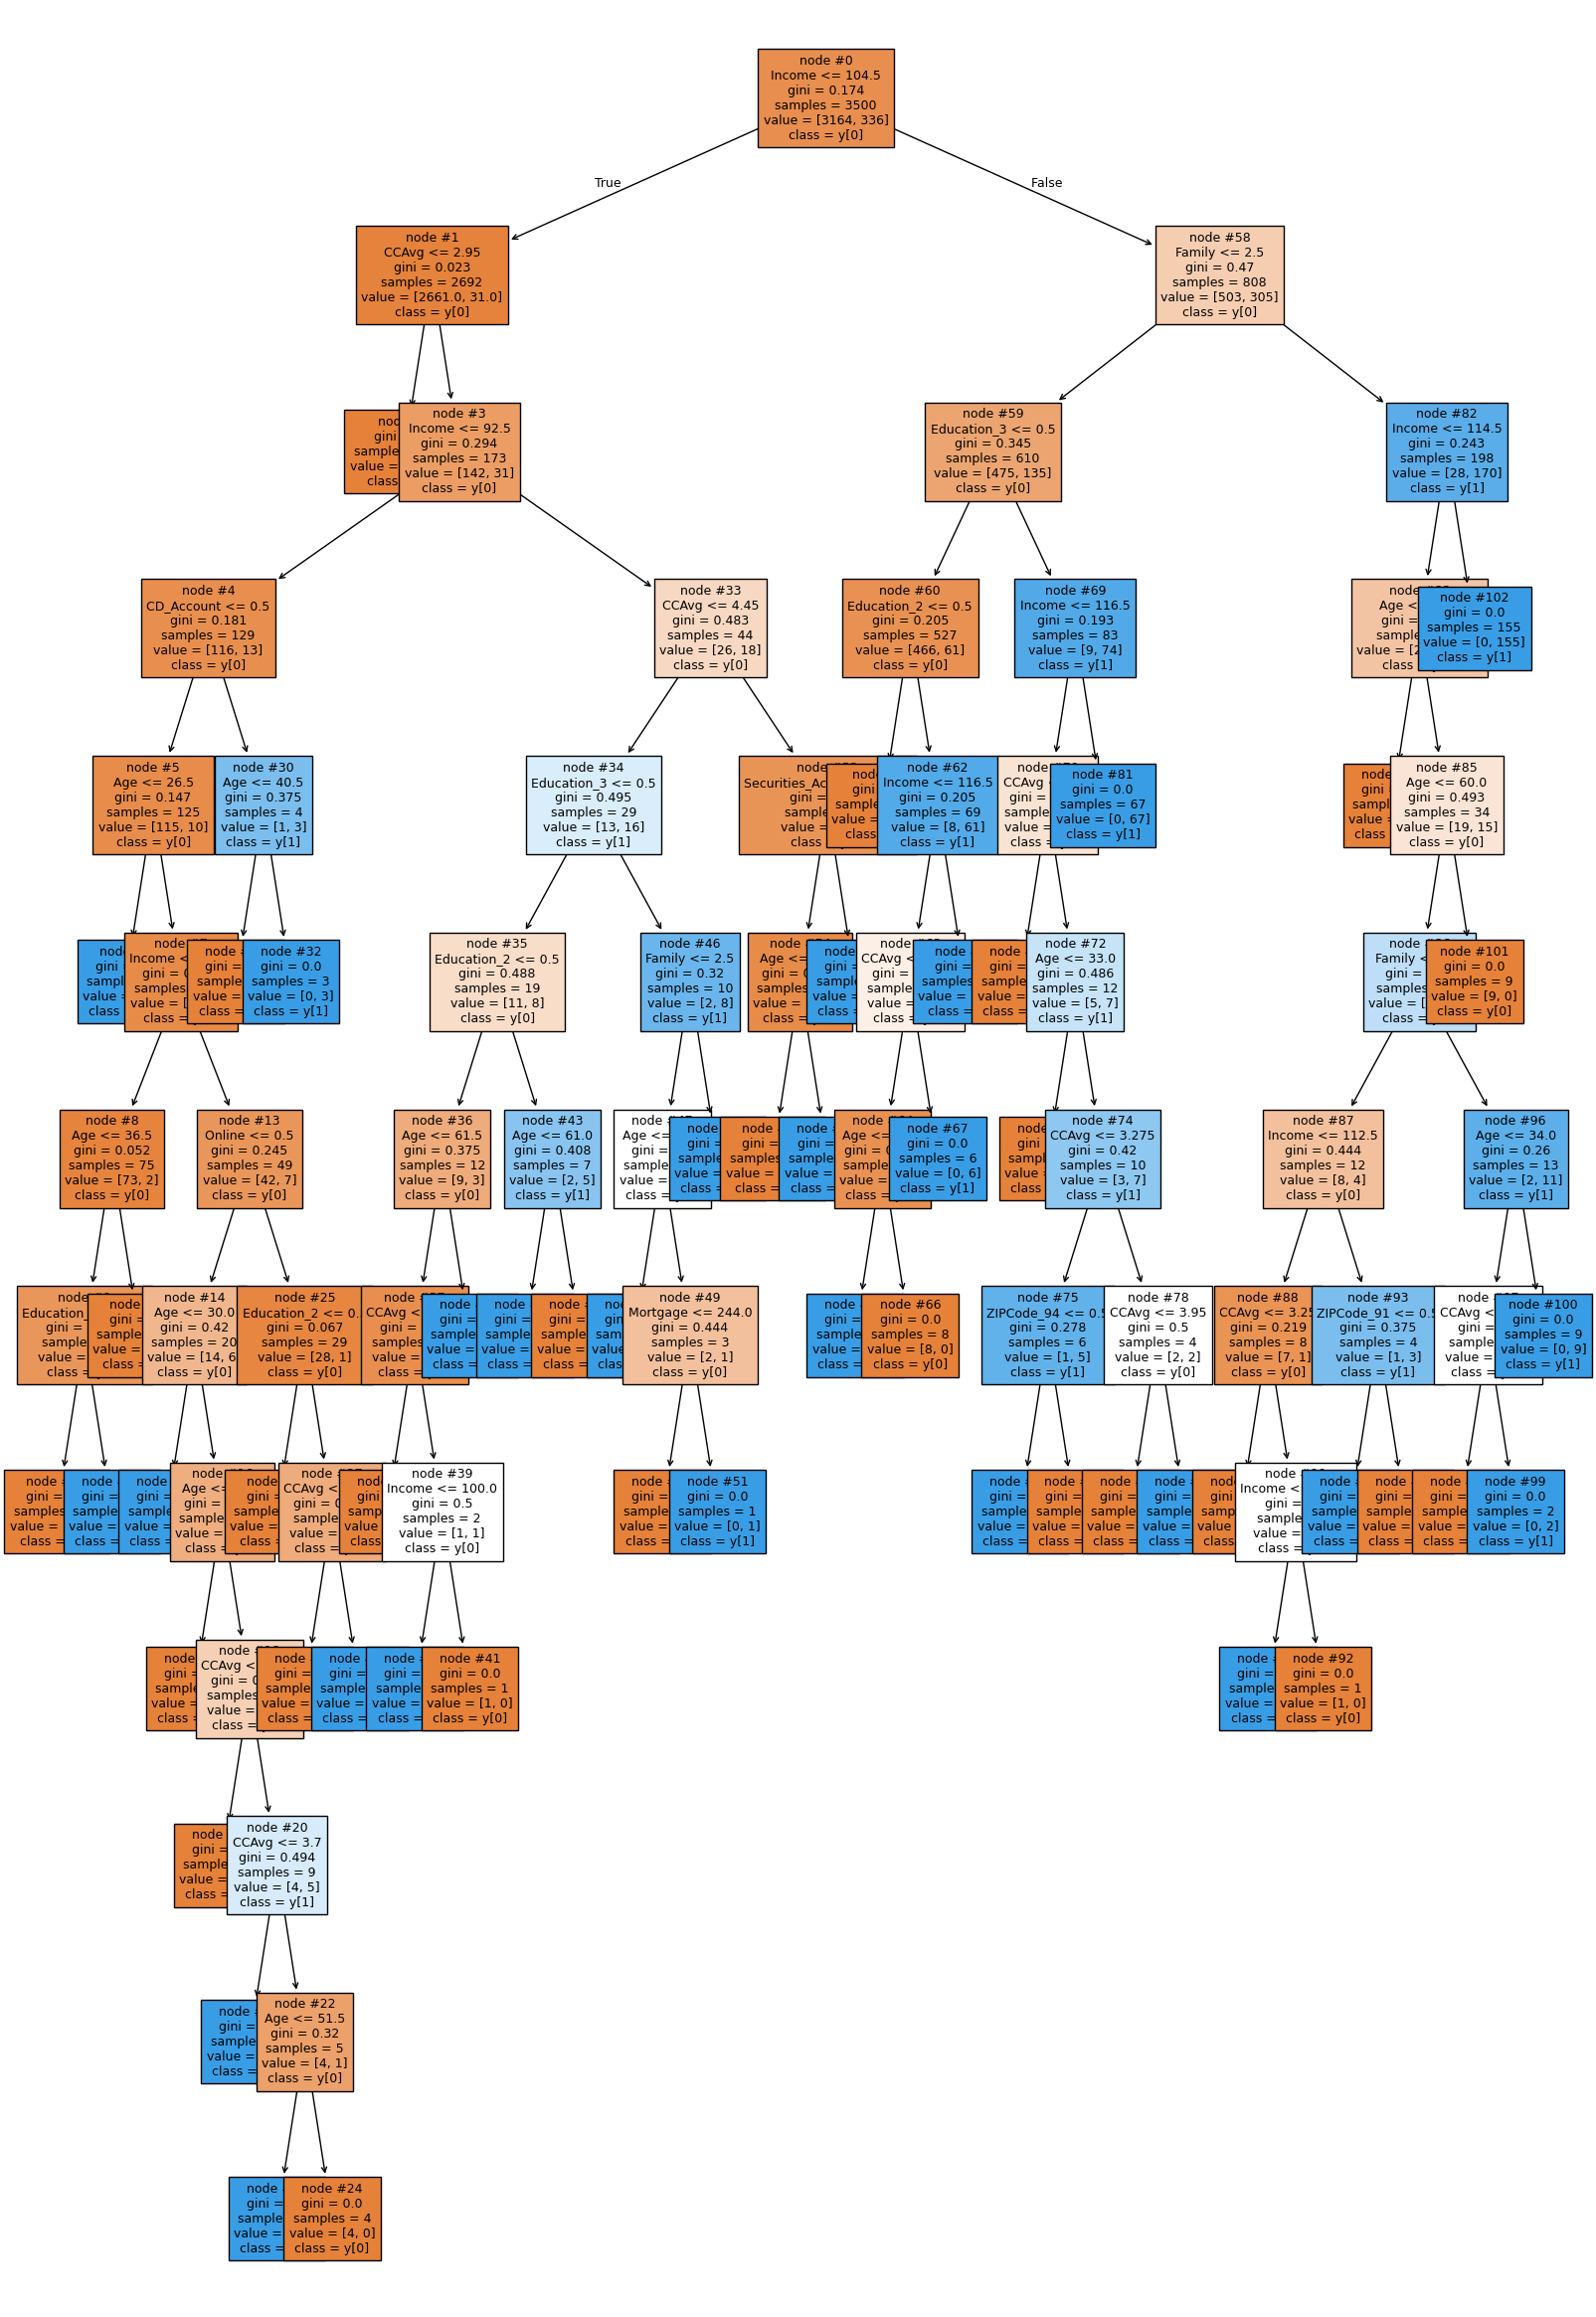

In [163]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [164]:
print(tree.export_text(model, feature_names=feature_names, show_weights=True))

|--- Income <= 104.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2519.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- Income <= 92.50
|   |   |   |--- CD_Account <= 0.50
|   |   |   |   |--- Age <= 26.50
|   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |--- Age >  26.50
|   |   |   |   |   |--- Income <= 81.50
|   |   |   |   |   |   |--- Age <= 36.50
|   |   |   |   |   |   |   |--- Education_2 <= 0.50
|   |   |   |   |   |   |   |   |--- weights: [12.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- Education_2 >  0.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |--- Age >  36.50
|   |   |   |   |   |   |   |--- weights: [61.00, 0.00] class: 0
|   |   |   |   |   |--- Income >  81.50
|   |   |   |   |   |   |--- Online <= 0.50
|   |   |   |   |   |   |   |--- Age <= 30.00
|   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |--- Age >  30.00
|   |   |   |   | 

###Feature Importance

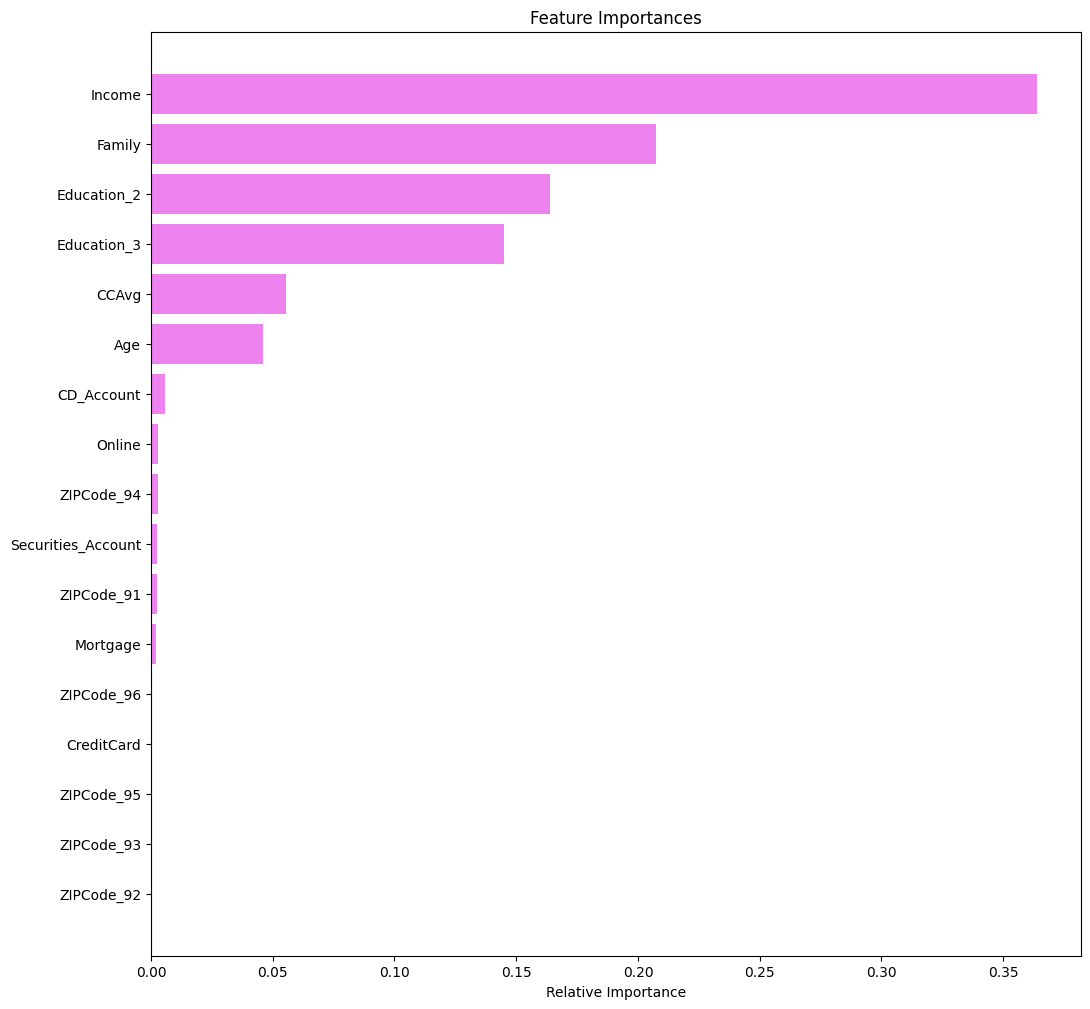

In [165]:
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###**Observations:**
For the default decision tree model, Income, family size, Education levels 2 and 3 ,CCAvg and Age seems to be the most important features.

## **Model Performance Improvement**

We will perform pruning techniques to reduce the overfitting.

##**Decision Tree- Pre Pruning with Unbalanced Class Weights**

I have removed class_weight='balanced'

In [166]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                #class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# creating an instance of the best model
model1 = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 6
Max leaf nodes: 50
Min samples split: 30
Best test recall score: 0.9097222222222222


###**Observations for class-weight= Balanced Tree:**

Best parameters found:
* Max depth: 2
* Max leaf nodes: 50
* Min samples split: 10
* Best test recall score: 1.0

* I intitally ran this model for balanced weight and found the the Max depth of the tree was only 2. It looks like the pre-pruned tree with balanced weights did not take into account other important features.

* The Recall score was as high as 1 for both train and test dataset with class weights balanced. However, all the other evaluation criteria were low with the precision at 0.32 and F1 at 0.48 for train , precision at 0.34 and F1 at 0.51 for Test data.


###**Observations after removing class-Weight=balanced**
The pre-pruned tree after removing the class-weight=balanced has a max_depth of 6 and the best test recall score of 0.909.

In [167]:
# Fit the best algorithm to the data.
estimator = best_estimator
estimator.fit(X_train,y_train) ## Complete the code to fit model on train data
y_train_pred = estimator.predict(X_train)
y_test_pred = estimator.predict(X_test)

###**Confusion Matrix on Training set**

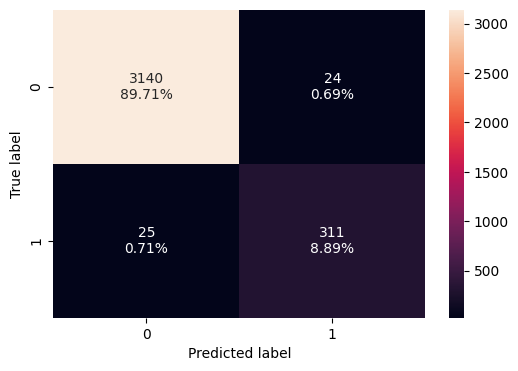

In [168]:
confusion_matrix_sklearn(model1,X_train,y_train)

###**Checking model on Training set**

In [169]:
decision_tree_preprun_perf_train = model_performance_classification_sklearn(
    model1, X_train, y_train
)
decision_tree_preprun_perf_train

,Accuracy,Recall,Precision,F1
0,0.986,0.925595,0.928358,0.926975


###**Confusion Matrix on Test data**

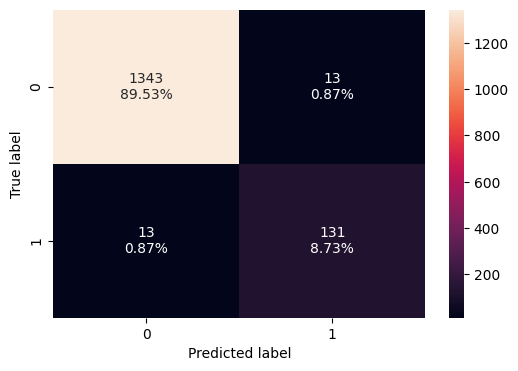

In [170]:
confusion_matrix_sklearn(model1,X_test,y_test)

###**Checking model on Test set**



In [171]:
decision_tree_preprun_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)
decision_tree_preprun_perf_test

,Accuracy,Recall,Precision,F1
0,0.982667,0.909722,0.909722,0.909722


###**Observations:**
* We can see that the recall score on train dataset is 0.92 while on test is slightly lower around 0.909.The F1 score is higher than the pre-pruned tree with class weights balanced.

* I prefer the model without the balanced weights as it takes all important features into consideration and also seems to generalize well on unseen data.

## **Plot Pre-Pruned Tree**

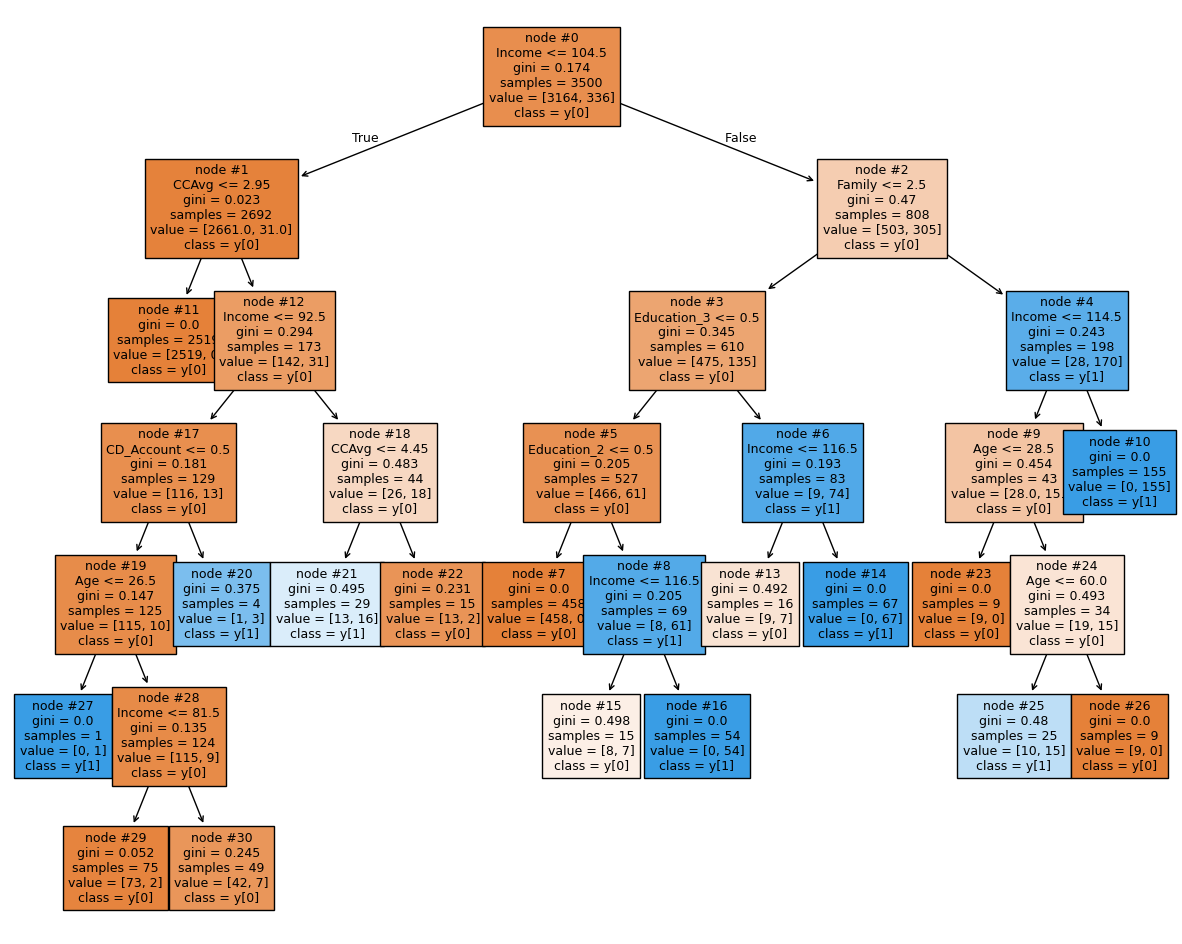

In [172]:
plt.figure(figsize=(15, 12))

tree.plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
plt.show()

In [173]:
print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

|--- Income <= 104.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2519.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- Income <= 92.50
|   |   |   |--- CD_Account <= 0.50
|   |   |   |   |--- Age <= 26.50
|   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |--- Age >  26.50
|   |   |   |   |   |--- Income <= 81.50
|   |   |   |   |   |   |--- weights: [73.00, 2.00] class: 0
|   |   |   |   |   |--- Income >  81.50
|   |   |   |   |   |   |--- weights: [42.00, 7.00] class: 0
|   |   |   |--- CD_Account >  0.50
|   |   |   |   |--- weights: [1.00, 3.00] class: 1
|   |   |--- Income >  92.50
|   |   |   |--- CCAvg <= 4.45
|   |   |   |   |--- weights: [13.00, 16.00] class: 1
|   |   |   |--- CCAvg >  4.45
|   |   |   |   |--- weights: [13.00, 2.00] class: 0
|--- Income >  104.50
|   |--- Family <= 2.50
|   |   |--- Education_3 <= 0.50
|   |   |   |--- Education_2 <= 0.50
|   |   |   |   |--- weights: [458.00, 0.00] class: 0
|   |   |   |--- Education_2 >  0.50

##Feature Importance for Pre-Pruned Decision Tree

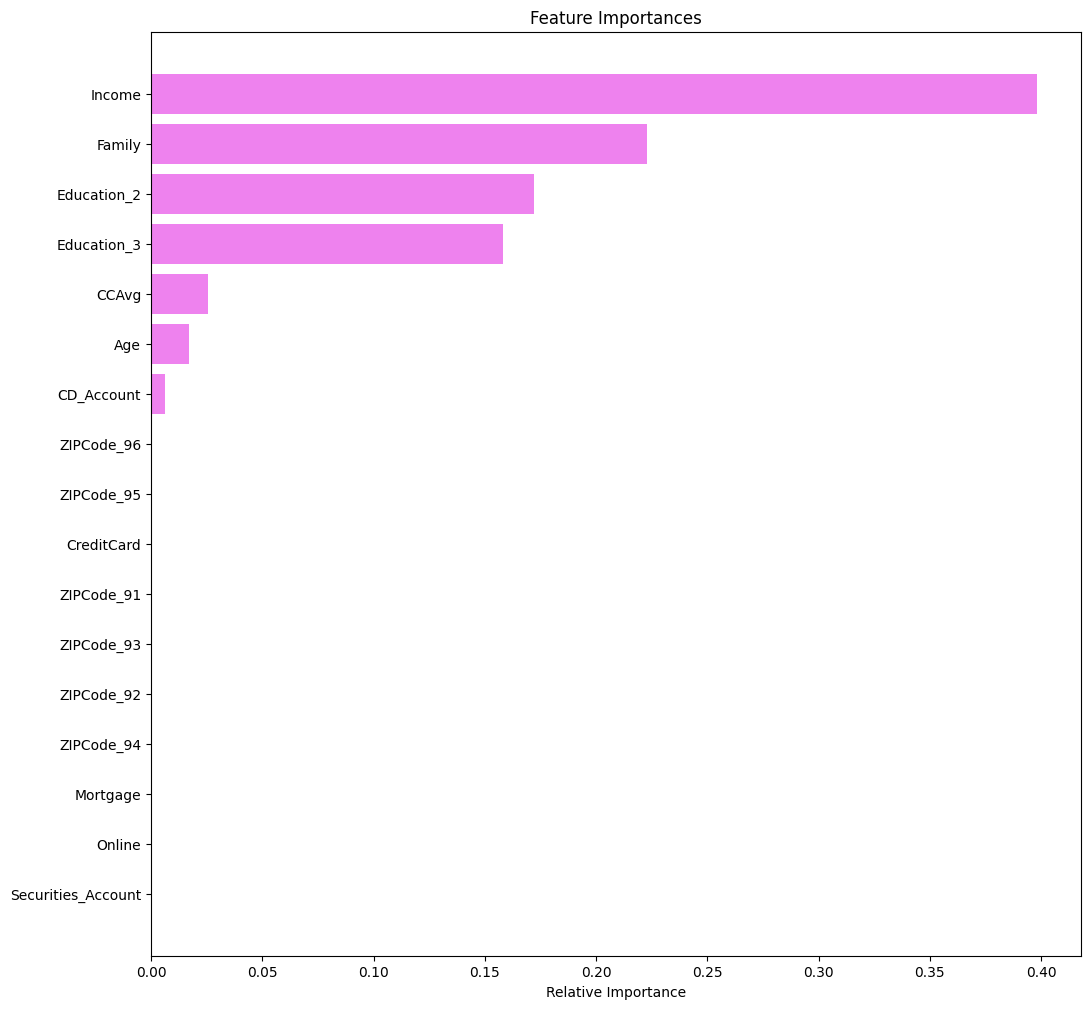

In [174]:
importances = model1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()


###**Observations:**
For the pre-pruned unbalanced class weights - Income,family size, education levels 2 and 3, CCAvg,Age are the most important features.

#Post Prunning of Decision tree

In [175]:
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [176]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000250,0.000500
2,0.000257,0.001014
3,0.000276,0.001566
4,0.000286,0.002137
5,0.000343,0.002480
6,0.000400,0.003680
7,0.000429,0.004109
8,0.000429,0.004537
9,0.000457,0.004995


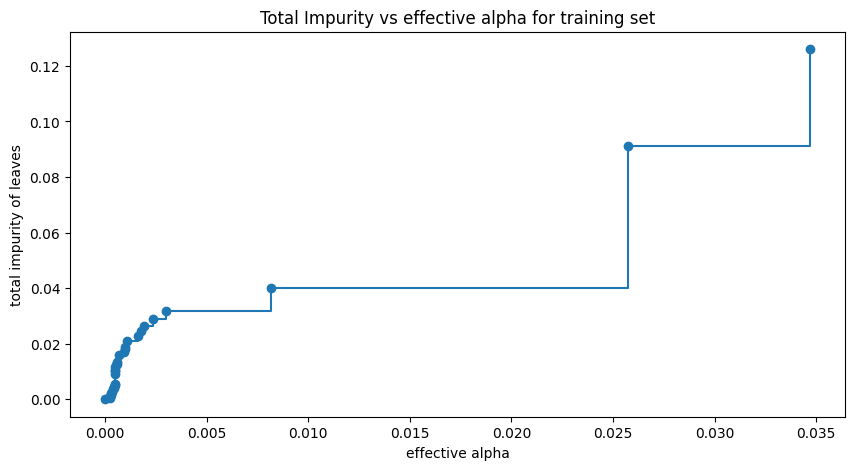

In [177]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

###**Observations:**
* As nodes are removed and impurity increases, as expected ccp_alpha also increases.

In [178]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.04756053380018527


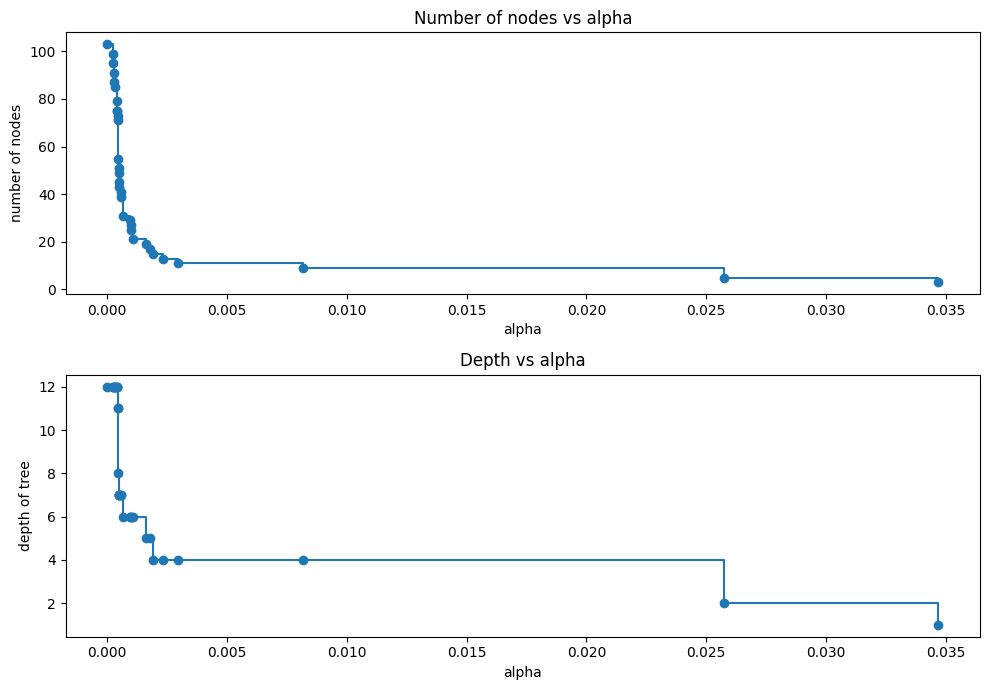

In [179]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

###**Observations:**
* We can see that the number of nodes and tree depth decreases as alpha increases.

##Recall vs alpha for training and testing sets

In [180]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [181]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

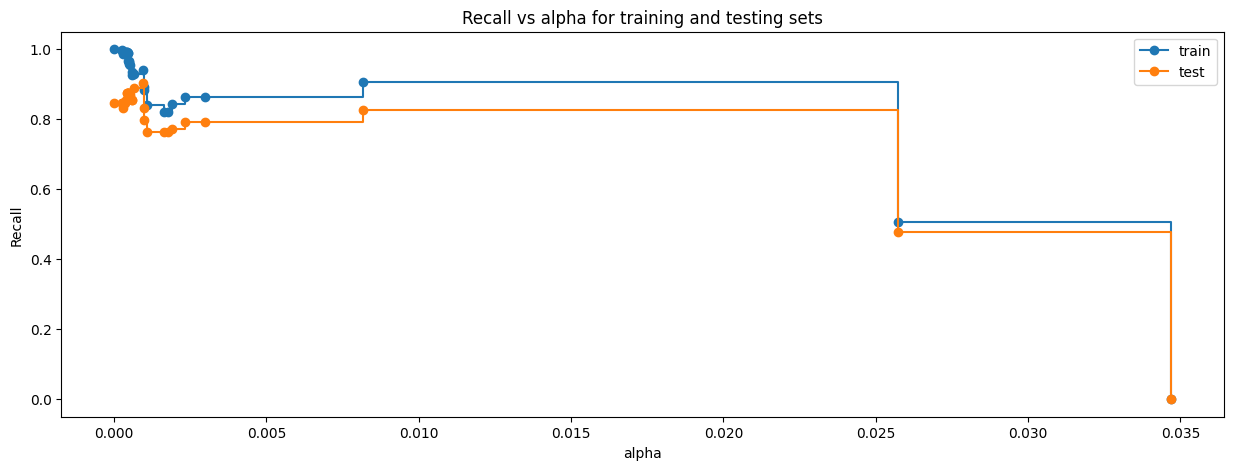

In [182]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

###**Observation:**
* In this graph we can see that the training data has the highest recall as starting point, levels out and finally drops to 0.035 as complexity increases.
* The test data starts at a lower recall values , levels and meets the training data before dropping.

In [183]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0009377289377289376),
                       random_state=1)


##Checking model performance on training set

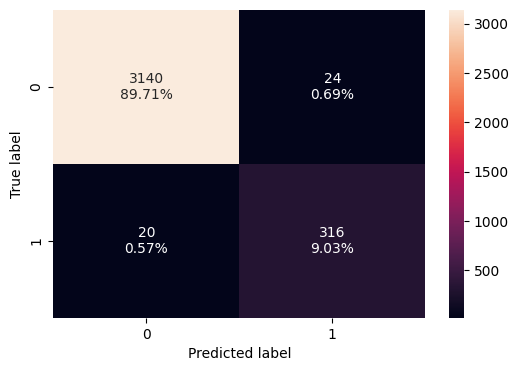

In [184]:
model2 = best_model
confusion_matrix_sklearn(model2,X_train,y_train)

In [185]:
decision_tree_postpruned_perf_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_postpruned_perf_train

,Accuracy,Recall,Precision,F1
0,0.987429,0.940476,0.929412,0.934911


##Checking model performance on test set

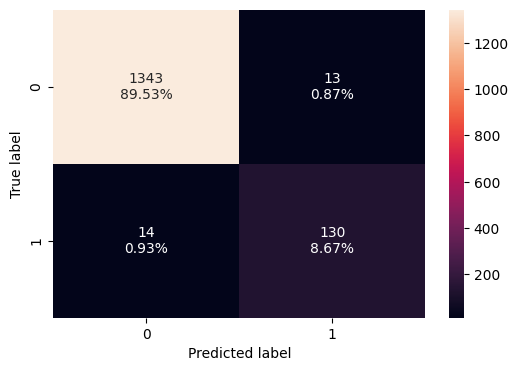

In [186]:
model2 = best_model
confusion_matrix_sklearn(model2,X_test,y_test)

In [187]:
decision_tree_postpruned_perf_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_postpruned_perf_test

,Accuracy,Recall,Precision,F1
0,0.982,0.902778,0.909091,0.905923


###**Observations:**
The post pruned tree has a recall of 0.94 on train data and 0.902 on test data. The F1 score is 0.93 on train and 0.905 on test.
The model seems to generalize fairly well with unseen test data.

##Visualize Post Prunned Decision tree

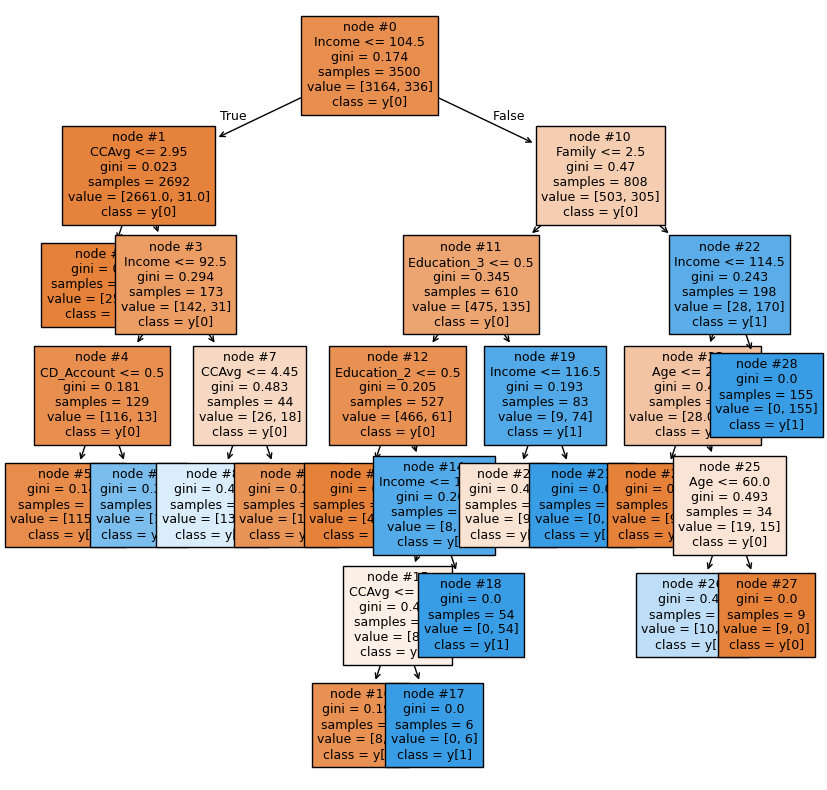

In [188]:
plt.figure(figsize=(10, 10))

out = tree.plot_tree(
    model2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()
plt.show()

In [189]:
print(tree.export_text(model2, feature_names=feature_names, show_weights=True))

|--- Income <= 104.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2519.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- Income <= 92.50
|   |   |   |--- CD_Account <= 0.50
|   |   |   |   |--- weights: [115.00, 10.00] class: 0
|   |   |   |--- CD_Account >  0.50
|   |   |   |   |--- weights: [1.00, 3.00] class: 1
|   |   |--- Income >  92.50
|   |   |   |--- CCAvg <= 4.45
|   |   |   |   |--- weights: [13.00, 16.00] class: 1
|   |   |   |--- CCAvg >  4.45
|   |   |   |   |--- weights: [13.00, 2.00] class: 0
|--- Income >  104.50
|   |--- Family <= 2.50
|   |   |--- Education_3 <= 0.50
|   |   |   |--- Education_2 <= 0.50
|   |   |   |   |--- weights: [458.00, 0.00] class: 0
|   |   |   |--- Education_2 >  0.50
|   |   |   |   |--- Income <= 116.50
|   |   |   |   |   |--- CCAvg <= 2.85
|   |   |   |   |   |   |--- weights: [8.00, 1.00] class: 0
|   |   |   |   |   |--- CCAvg >  2.85
|   |   |   |   |   |   |--- weights: [0.00, 6.00] class: 1
|   |   |   |   |--- Income >  116.5

In [190]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the 'criterion' brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        model2.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Income              0.394248
Family              0.221507
Education_2         0.171008
Education_3         0.157481
CCAvg               0.035660
Age                 0.013747
CD_Account          0.006349
Mortgage            0.000000
Securities_Account  0.000000
CreditCard          0.000000
Online              0.000000
ZIPCode_91          0.000000
ZIPCode_92          0.000000
ZIPCode_93          0.000000
ZIPCode_94          0.000000
ZIPCode_95          0.000000
ZIPCode_96          0.000000


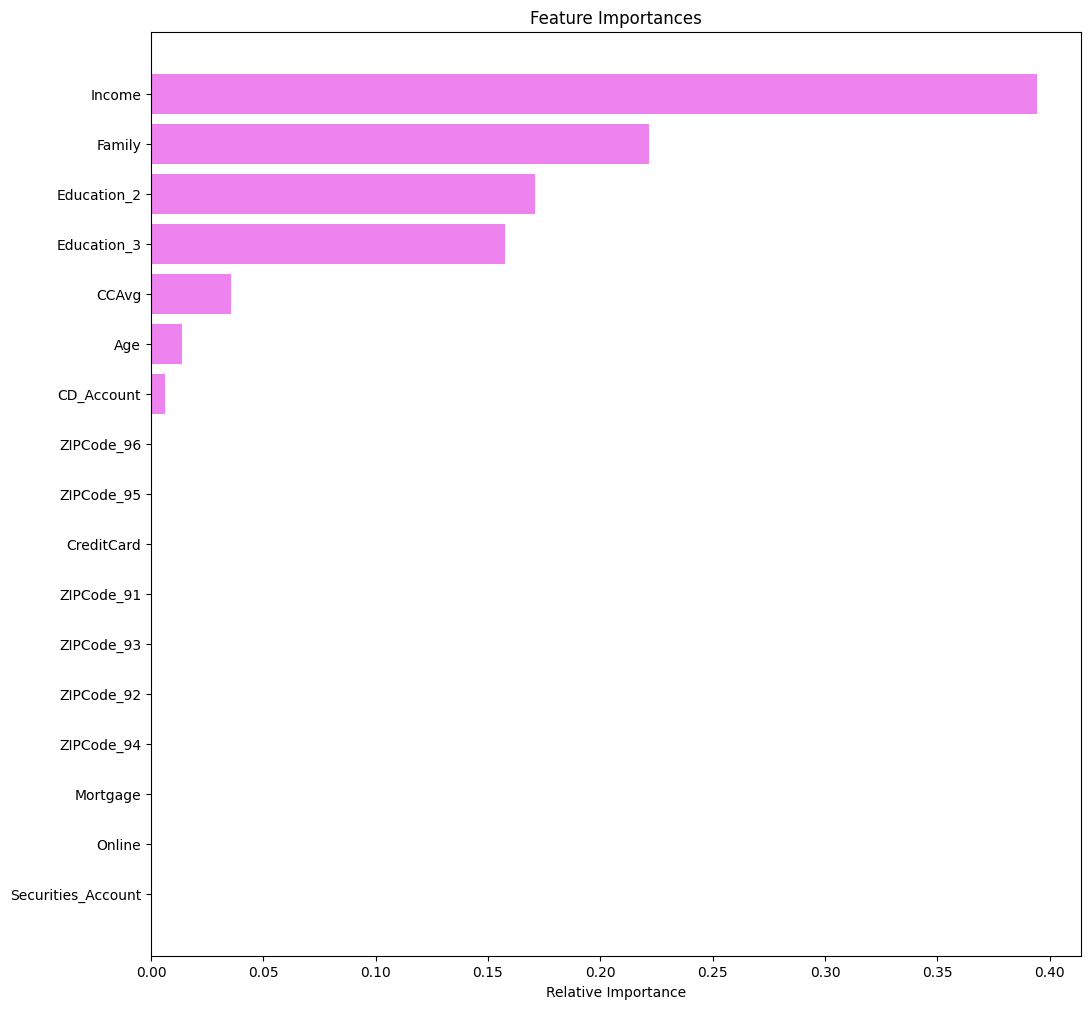

In [191]:
importances = model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###**Observations:**
The most important features for the post pruned tree are Income, Education levels 2,3, Family size, CCAvg and Age.

## Model Performance Comparison and Final Model Selection

In [192]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_preprun_perf_train.T,
        decision_tree_postpruned_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.986000,0.987429
Recall,1.0,0.925595,0.940476
Precision,1.0,0.928358,0.929412
F1,1.0,0.926975,0.934911


In [193]:
# test performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_preprun_perf_test.T,
        decision_tree_postpruned_perf_test.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_train_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.979333,0.982667,0.982000
Recall,0.847222,0.909722,0.902778
Precision,0.931298,0.909722,0.909091
F1,0.887273,0.909722,0.905923


###**Observations**
* The decision tree model with the unbalanced class weights Pre-Pruned tree has the highest Recall score on test data.

* Therefore, we are chossing the pre-pruned (class-weight=balanced removed) model as the best model.

## **Actionable Insights and Business Recommendations**


* What recommedations would you suggest to the bank?

1. Income, family size, education level, average credit card spending, and age are key indicators of customers likely to take personal loans.

2. High-income earners with graduate or advanced degrees, larger families, and higher credit card spending are more inclined to seek loans.

3. All Life Bank should target these segments with tailored loan packages for purposes like education, travel & vacation spending, and home improvement, etc.



___